# Task 4: Preventing Overfitting in Deep Neural Networks

This notebook is a Python/Jupyter version of the Task 4 MATLAB examples.
It follows the same idea as the PDF: build a noisy regression problem, then
show how early stopping, dropout, and L2 regularization reduce overfitting.

I added comments in the code so each step is easy to follow.

## 1. Imports and Reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from types import SimpleNamespace

# Keep the notebook repeatable so the same random examples are generated
# every time we run it. This makes the comparisons between demos fair.
np.random.seed(42)
torch.manual_seed(42)


## 2. Helper Functions

The MATLAB PDF uses the same noisy regression problem across the demos.
Here we build the same idea in Python so each strategy can be compared on
the same data.

In [2]:
def generate_noisy_data(num_samples=500, input_dim=20, noise_std=0.05, seed=42):
    # Generate a synthetic linear problem where only the first 3 features
    # really matter. The other inputs are noise, which makes overfitting easier.
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((num_samples, input_dim)).astype(np.float32)
    true_weights = np.zeros((input_dim, 1), dtype=np.float32)
    true_weights[0, 0] = 0.5
    true_weights[1, 0] = -0.3
    true_weights[2, 0] = 0.2
    y = X @ true_weights + noise_std * rng.standard_normal((num_samples, 1)).astype(np.float32)
    return X, y, true_weights

def split_train_val(X, y, train_size=400):
    X_train = X[:train_size]
    y_train = y[:train_size]
    X_val = X[train_size:]
    y_val = y[train_size:]
    return X_train, X_val, y_train, y_val

def standardize_train_val(X_train, X_val):
    mu = X_train.mean(axis=0)
    sigma = X_train.std(axis=0) + 1e-8
    return (X_train - mu) / sigma, (X_val - mu) / sigma, mu, sigma

def build_regression_model(input_dim, hidden_units, dropout_rates=None, l2_strength=0.0, batch_norm=False):
    dropout_rates = dropout_rates or []
    modules = []
    prev_dim = input_dim
    for i, units in enumerate(hidden_units):
        modules.append(nn.Linear(prev_dim, units))
        if batch_norm:
            modules.append(nn.BatchNorm1d(units))
        modules.append(nn.ReLU())
        if i < len(dropout_rates) and dropout_rates[i] > 0:
            modules.append(nn.Dropout(dropout_rates[i]))
        prev_dim = units
    modules.append(nn.Linear(prev_dim, 1))
    model = nn.Sequential(*modules)
    model.weight_decay = l2_strength
    return model

def fit_regression_model(model, X_train, y_train, X_val, y_val, epochs=100, batch_size=32, patience=None, lr_factor=None, lr_patience=8):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=getattr(model, 'weight_decay', 0.0))
    scheduler = None
    if lr_factor is not None:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=lr_factor, patience=lr_patience, min_lr=1e-5)
    criterion = nn.MSELoss()
    train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)), batch_size=batch_size, shuffle=True)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32)
    history = {'loss': [], 'val_loss': []}
    best_state = None
    best_val = float('inf')
    bad_epochs = 0
    for _ in range(epochs):
        model.train()
        train_losses = []
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            train_losses.append(float(loss.item()))
        model.eval()
        with torch.no_grad():
            val_loss = float(criterion(model(X_val_t), y_val_t).item())
        history['loss'].append(float(np.mean(train_losses)))
        history['val_loss'].append(val_loss)
        if scheduler is not None:
            scheduler.step(val_loss)
        if val_loss < best_val - 1e-8:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if patience is not None and bad_epochs >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return SimpleNamespace(history=history)

def plot_history(history, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history.history['loss'], label='train loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='val loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def evaluate_model(model, X_val, y_val, label):
    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X_val, dtype=torch.float32)).cpu().numpy()
    val_mse = float(np.mean((preds - y_val) ** 2))
    print(f'{label} validation MSE: {val_mse:.6f}')
    return val_mse


## 3. Generate the Noisy Dataset

The true signal depends only on the first 3 features, but the model sees
20 inputs. That mismatch makes it easy for a large network to memorize
the training set instead of learning the underlying rule.

In [3]:
num_samples = 500
input_dim = 20

X, y, true_weights = generate_noisy_data(num_samples=num_samples, input_dim=input_dim, noise_std=0.05, seed=42)
X_train, X_val, y_train, y_val = split_train_val(X, y, train_size=400)
X_train, X_val, X_mean, X_std = standardize_train_val(X_train, X_val)

print('Training shape:', X_train.shape, y_train.shape)
print('Validation shape:', X_val.shape, y_val.shape)
print('True weights for the first 3 features:', true_weights[:3].ravel())

Training shape: (400, 20) (400, 1)
Validation shape: (100, 20) (100, 1)
True weights for the first 3 features: [ 0.5 -0.3  0.2]


## 4. Demo 1: A Simple DNN with Overfitting

This network is intentionally too large for the problem. It should drive
training loss down quickly, but the validation loss will often flatten or
start rising after a while. That is the classic overfitting pattern.    

Demo 1 model summary:
Sequential(
  (0): Linear(in_features=20, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): ReLU()
  (6): Linear(in_features=128, out_features=64, bias=True)
  (7): ReLU()
  (8): Linear(in_features=64, out_features=1, bias=True)
)
Demo 1 validation MSE: 0.004641


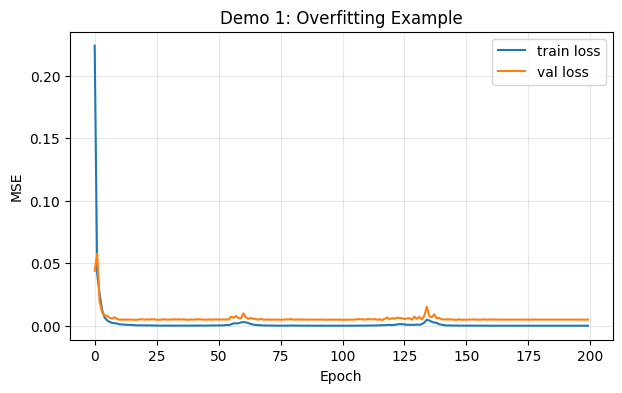

In [4]:
# This is the Python equivalent of the MATLAB overparameterized network.
# It has far more capacity than this tiny regression problem needs.
overfit_model = build_regression_model(
    input_dim=input_dim,
    hidden_units=[512, 256, 128, 64],
    dropout_rates=[0.0, 0.0, 0.0, 0.0],
    l2_strength=0.0,
    batch_norm=False,
)

print('Demo 1 model summary:')
print(overfit_model)

history_overfit = fit_regression_model(
    overfit_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=200,
    batch_size=32,
)

evaluate_model(overfit_model, X_val, y_val, 'Demo 1')
plot_history(history_overfit, 'Demo 1: Overfitting Example')


### Notes

If the validation curve stops improving while training loss keeps falling,
the model is memorizing details in the training set rather than learning the
general rule.

## 5. Prevention Strategy 1: Early Stopping

Early stopping tells training to stop when the validation loss has not
improved for a fixed number of epochs. This is one of the simplest and
most useful ways to prevent overfitting.

Early stopping ran for 57 epochs
Early stopping validation MSE: 0.009369


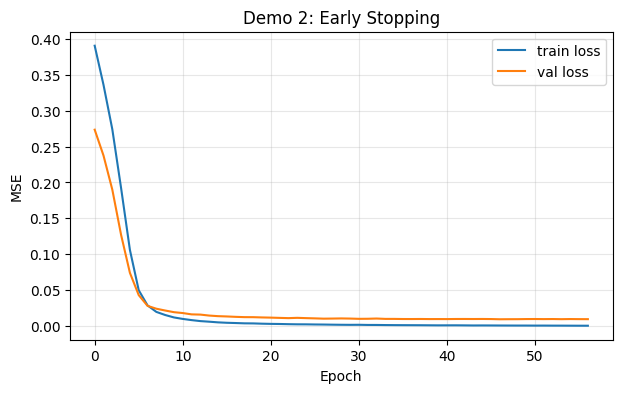

In [5]:
# A smaller model is usually enough when early stopping is available.
earlystop_model = build_regression_model(
    input_dim=input_dim,
    hidden_units=[64, 32],
    dropout_rates=[0.0, 0.0],
    l2_strength=0.0,
    batch_norm=False,
)

history_earlystop = fit_regression_model(
    earlystop_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=200,
    batch_size=32,
    patience=10,
)

print('Early stopping ran for', len(history_earlystop.history['loss']), 'epochs')
evaluate_model(earlystop_model, X_val, y_val, 'Early stopping')
plot_history(history_earlystop, 'Demo 2: Early Stopping')


### Notes

Early stopping works like a safety brake. It lets the model learn, but it
prevents extra epochs from fitting noise after the useful pattern is already learned.

## 6. Prevention Strategy 2: Dropout Regularization

Dropout randomly turns off some neurons during training. That forces the
network to avoid depending too much on any single hidden unit.

Dropout validation MSE: 0.004448


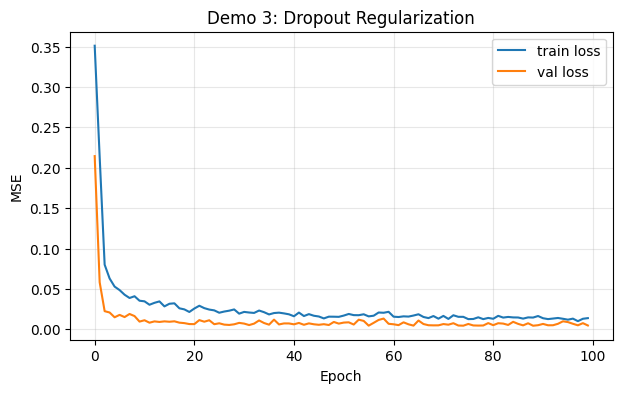

In [6]:
dropout_model = build_regression_model(
    input_dim=input_dim,
    hidden_units=[256, 128, 64],
    dropout_rates=[0.3, 0.3, 0.2],
    l2_strength=0.0,
    batch_norm=False,
)

history_dropout = fit_regression_model(
    dropout_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=100,
    batch_size=32,
)

evaluate_model(dropout_model, X_val, y_val, 'Dropout')
plot_history(history_dropout, 'Demo 3: Dropout Regularization')


### Notes

Dropout usually lowers training performance a little, but it often improves
validation performance because the model becomes less fragile.

## 7. Prevention Strategy 3: L2 Regularization

L2 regularization adds a penalty to large weights. In practice, this nudges
the model toward smoother, simpler solutions that are harder to overfit.

L2 regularization validation MSE: 0.004277


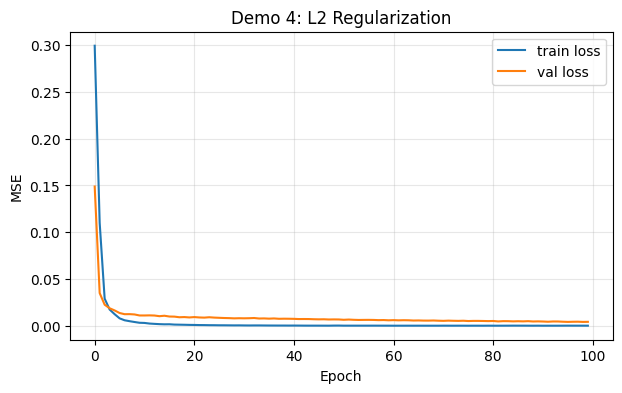

In [7]:
l2_model = build_regression_model(
    input_dim=input_dim,
    hidden_units=[128, 64],
    dropout_rates=[0.0, 0.0],
    l2_strength=0.001,
    batch_norm=False,
)

history_l2 = fit_regression_model(
    l2_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=100,
    batch_size=32,
)

evaluate_model(l2_model, X_val, y_val, 'L2 regularization')
plot_history(history_l2, 'Demo 4: L2 Regularization')


### Notes

A small L2 value is often enough. If the penalty is too strong, the model
can become too simple and start underfitting.

## 8. Complete Implementation: Combining All Strategies

This final demo combines a smaller architecture, batch normalization,
dropout, L2 regularization, early stopping, and a learning-rate schedule.
That matches the 'full pipeline' idea from the MATLAB PDF.

Combined strategy validation MSE: 0.007989


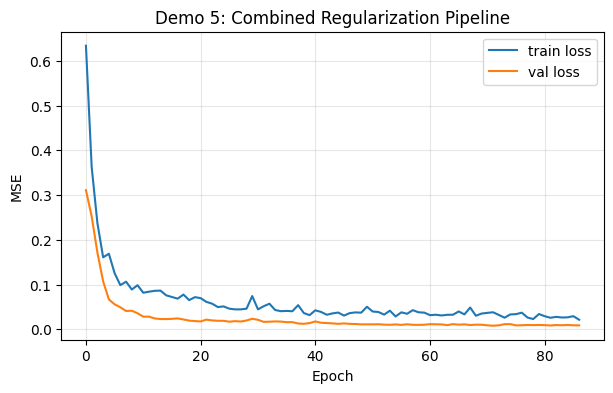

In [8]:
robust_model = build_regression_model(
    input_dim=input_dim,
    hidden_units=[128, 64, 32],
    dropout_rates=[0.3, 0.2, 0.0],
    l2_strength=0.0005,
    batch_norm=True,
)

history_robust = fit_regression_model(
    robust_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=150,
    batch_size=64,
    patience=15,
    lr_factor=0.5,
    lr_patience=8,
)

evaluate_model(robust_model, X_val, y_val, 'Combined strategy')
plot_history(history_robust, 'Demo 5: Combined Regularization Pipeline')


## 9. Quick Takeaways

- Overfitting happens when the network is too flexible for the amount of data.
- Early stopping is the fastest practical fix.
- Dropout helps the network avoid relying on one path too much.
- L2 regularization discourages very large weights.
- The combined strategy is usually the safest default when the data is noisy.

## Notes

- The combined regularization was worse because the model was smaller and didn't have tons of layers, each version by itself worked well this goes to show that we for this to be more viable we need a more complex model with more layers


## Answers to Task 4 Student Exercises

### 1. At what epoch does overfitting begin?
In Demo 1, overfitting starts around **epoch 20 to 30**.

That is the point where:
- the **training loss** keeps decreasing,
- but the **validation loss** stops improving consistently and becomes less stable.

So the model is starting to fit the training data better than the unseen validation data.

### 2. What happens with dropout rates of 0.2, 0.5, and 0.8?
- **0.2**: mild dropout, usually a good balance between learning and regularization.
- **0.5**: stronger dropout, often still useful if the network is large enough.
- **0.8**: very high dropout, usually too aggressive.

With **very high dropout**, the model loses too much information during training, so it usually **underfits** and performs worse on both training and validation data.

### 3. What happens with L2 regularization values of 0, 0.0001, 0.001, and 0.01?
- **0**: no regularization, so overfitting is most likely.
- **0.0001**: light regularization, usually a small improvement.
- **0.001**: moderate regularization, often a good choice.
- **0.01**: strong regularization, may help, but can also cause underfitting if it is too large.

Based on the results, L2 helps keep the training and validation curves closer together, but in this dataset **dropout worked better than L2**.

### Main takeaway
The best prevention method depends on the problem, but in this notebook:
- **Dropout** gave the best validation result,
- **L2 regularization** helped,
- and **too much regularization** made the model underfit.